<a href="https://colab.research.google.com/github/AnabelGP/An-lisis-estad-stico-b-sico/blob/main/Pruebas_gr%C3%A1ficos_estad%C3%ADstica_inferencia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Caso práctico: Análisis con pandas, seaborn y scipy-stats

### Información general

**Descripción:** En el presente cuaderno se van a estudiar los datos proporcionados de los estudiantes de la Universidad Salamanca. Se realizará un estudio estadístico descriptivo e inferencial. Además, se proporcionarán gráficos que facilitarán el entendimeinto de los datos.

**Autor**: Anabel Gallego Pérez

**Fecha**: 27/03/2026

**Correo Electrónico**: anabelgallego.fisioterapeuta@gmail.com

**Python 3.14.3**

**Jupyter lab**

### Librerías

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sb
import scipy.stats as stats
import matplotlib.pyplot as plt

### Importación de datos

In [ ]:
# Improtamos la base de datos en archivo cvs
df = pd.read_csv("student_data.csv")

# Visualizamos los primeros 5 datos de la base de datos importada
df.head()

,gender,age,parental_education_level,family_income,daily_study_hours,attendance_rate,sleep_hours,stress_level,motivation_score,private_tutoring,internet_quality,math_score,reading_score,writing_score,pass_fail
0,Female,15,2,45000.0,2.9,0.916,8.3,6.0,16,False,2,21,29,29,Fail
1,Male,19,2,15000.0,2.8,0.760,6.8,5.0,58,False,3,56,37,45,Fail
2,Female,20,5,55000.0,4.0,0.894,8.2,6.0,51,False,3,60,51,63,Fail
3,Female,16,5,65000.0,4.6,0.888,6.2,6.0,49,False,3,58,54,34,Fail
4,Male,20,4,35000.0,4.3,0.923,7.3,4.0,62,False,2,80,57,73,Pass


### Exploramos los datos, filtramos duplicados y datos nulos

In [ ]:
# Exploramos la base de datos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   gender                    200000 non-null  str    
 1   age                       200000 non-null  int64  
 2   parental_education_level  200000 non-null  int64  
 3   family_income             195975 non-null  float64
 4   daily_study_hours         200000 non-null  float64
 5   attendance_rate           200000 non-null  float64
 6   sleep_hours               195887 non-null  float64
 7   stress_level              196087 non-null  float64
 8   motivation_score          200000 non-null  int64  
 9   private_tutoring          200000 non-null  bool   
 10  internet_quality          200000 non-null  int64  
 11  math_score                200000 non-null  int64  
 12  reading_score             200000 non-null  int64  
 13  writing_score             200000 non-null  int64  
 14 

**Conclusión:** Estamos antes una base de datos que presenta in14 variables, de las cuales, la mayoría son cuantitativas y, solo 3 de ellas son cualitativas. Observamos que hay datos nulos en las columnas family incom, slepp hours y stress level. Por lo que exploramos más en profundidad dichas variables y datos nulos

**Análisis datos nulos**

In [ ]:
# Localizamos los datos

# Cuantificamos los datos nulos de las variables
df_nulos = df.isnull().sum() # Localizamos los datos nulos y los sumamos

# Establecemos la proporción de datos nulos de la base de datos
# Nulos > 5% de datos nulos--> Estrategia de sustitución según media o mediana (distribusión normal--> media, distribución no normal--> mediana)
# Nulos < 5% --> Eliminar los datos nulos
df_proporcion_nulos= ((df.isnull().sum()/len(df))*100).round(2) # Redondeamos a la 2 cifra decimal
# Nulos < 5% por varible

# Eliminación de los datos nulos
df = df.dropna()

# Informe de datos nulos
print ("========== INFORME DATOS NULOS ==========")
print("")
print("========== Cantidad de nulos: ")
print(df_nulos)
print("")
print("========== Proporción nulos: ")
print (df_proporcion_nulos)


========== INFORME DATOS NULOS ==========

========== Cantidad de nulos: 
gender                         0
age                            0
parental_education_level       0
family_income               4025
daily_study_hours              0
attendance_rate                0
sleep_hours                 4113
stress_level                3913
motivation_score               0
private_tutoring               0
internet_quality               0
math_score                     0
reading_score                  0
writing_score                  0
pass_fail                      0
dtype: int64

========== Proporción nulos: 
gender                      0.00
age                         0.00
parental_education_level    0.00
family_income               2.01
daily_study_hours           0.00
attendance_rate             0.00
sleep_hours                 2.06
stress_level                1.96
motivation_score            0.00
private_tutoring            0.00
internet_quality            0.00
math_score              

**Conclusión:** Debido a que los datos nulos constinuyen a menos del 5% en cada variable, aplicamos la solución de eliminado de datos nulos

**Comprobación de eliminación nulos:**

In [ ]:
# Comprobamos que hemos elimiando los datos
df.isnull().sum()

gender                      0
age                         0
parental_education_level    0
family_income               0
daily_study_hours           0
attendance_rate             0
sleep_hours                 0
stress_level                0
motivation_score            0
private_tutoring            0
internet_quality            0
math_score                  0
reading_score               0
writing_score               0
pass_fail                   0
dtype: int64

**Conclusión:** Los datos nulos han sido elimiando correctamente

### Agrupaciones simples con condiciones

In [ ]:
# Agrupación de datos según la media de math score según si han recibido o no clases privadas y solo de los alumnos que pasan el examen

# Condioción de pasar el examen
condicion1 = (df["pass_fail"] == "Pass")

# Creamos la agrupación de los datos por media en math score para estudiantes con tutoria privada o no según la condición 1
df[condicion1].groupby('private_tutoring')['math_score'].mean().round(2) # Redondeamos a 2 decimales la media de math_score

private_tutoring
False    70.79
True     78.87
Name: math_score, dtype: float64

### Gráfico

Gráficos de barras para las variables cualitativas

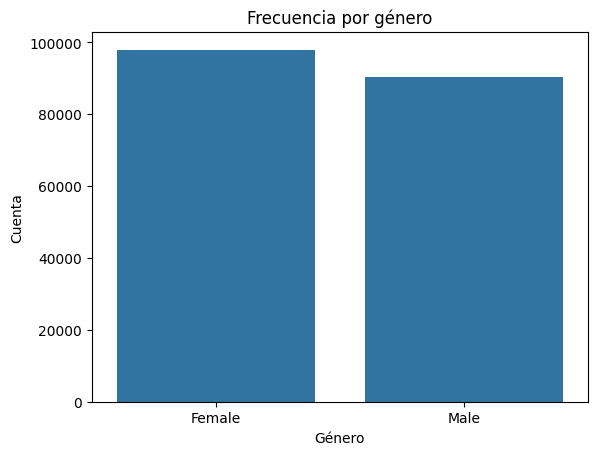

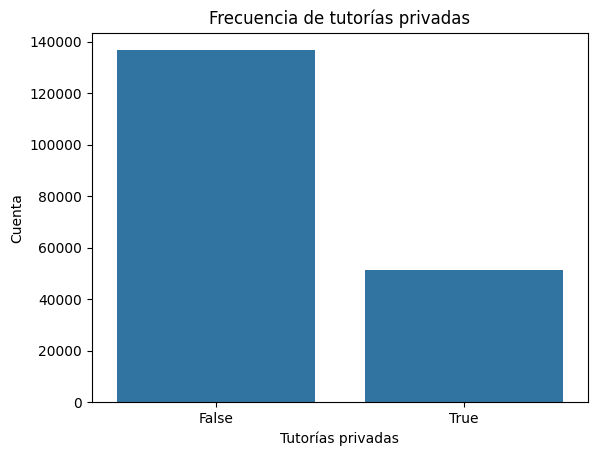

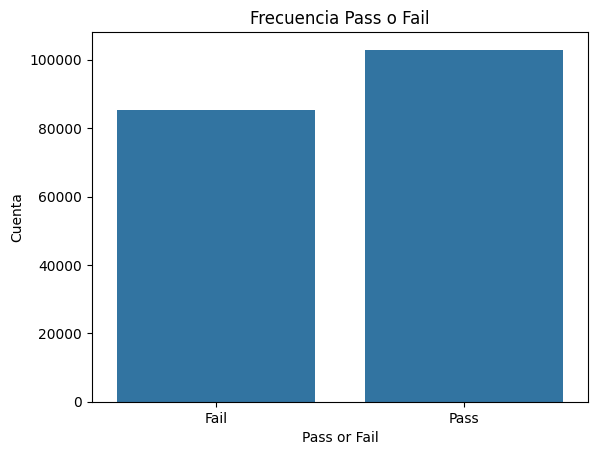

In [ ]:
# Diagrama de barras para vaiable "Gender"

sb.countplot(data=df, x="gender")
plt.title("Frecuencia por género")
plt.xlabel("Género")
plt.ylabel("Cuenta")
plt.show()

# Diagrama de barras para variable "private_tutoring"
sb.countplot(data=df, x="private_tutoring")
plt.title("Frecuencia de tutorías privadas")
plt.xlabel("Tutorías privadas")
plt.ylabel("Cuenta")
plt.show()

# Diagrama de barras para variable "pass_fail"
sb.countplot(data=df, x="pass_fail")
plt.title("Frecuencia Pass o Fail")
plt.xlabel("Pass or Fail")
plt.ylabel("Cuenta")
plt.show()


### Estadística inferencial

**Prueba de normalidad Kolmogorov–Smirnov**

In [ ]:
# Prueba de normalidad de Kolmogorov–Smirnov para variable math_score

# Datos
datos_math = df['math_score']

# Ajustar distribución normal para varibale math_score
mu, sigma = stats.norm.fit(datos_math)

# Prueba de Kolmogorov–Smirnov para variable math_score
stat, p_valor = stats.kstest(datos_math, 'norm', args=(mu, sigma))

print("Variable Math Score")
print("Estadístico KS:", stat)
print("p-valor:", p_valor)

Variable Math Score
Estadístico KS: 0.019619818763790986
p-valor: 2.340383615308788e-63


In [ ]:
# Prueba de normalidad de Kolmogorov–Smirnov para variable daily_study_hours
# Datos
datos_dsh = df['daily_study_hours']

# Ajustar distribución normal para varibale daily_study_hours
mu, sigma = stats.norm.fit(datos_dsh)

# Prueba de Kolmogorov–Smirnov para variable daily_study_hours
stat, p_valor = stats.kstest(datos_dsh, 'norm', args=(mu, sigma))

print("Variable daily_study_hours")
print("Estadístico KS:", stat)
print("p-valor:", p_valor)

Variable daily_study_hours
Estadístico KS: 0.08824437125709561
p-valor: 0.0


Debido a que estamos ante dos variables que no siguen una distribución normal según la prueba de Kolmogorov-Smirnov, vamos a ver si existe correlación entre estas dos variables con la correlación de Spearman

### Correlación de Spearman

In [ ]:
# Correlación de Spearman

# Coeficiente de Spearman entre las dos columnas
correlation_spearman = df['math_score'].corr(df['daily_study_hours'], method='spearman')

print(f"El coeficiente de correlación de Spearman es: {correlation_spearman}")

El coeficiente de correlación de Spearman es: 0.4001672770482048


P valor > 0.05, por lo que aceptamos la hipótesis nula que estable que no hay correlación entre la puntuación en matemáticas y las horas de estudio diaria. Por lo que no podemos establecer una relación entre la puntuación en matemáticas y las horas de estudio diarias, lo que hace imposible establecer, con esta base de datos, una causualidad entre ellas, ya que uno de los tres principios que necesitamos para poder decir que existe causalidad es que exista correlación entre las variables.